# Estudio dqdv y ajustes sobre NMC 45°C parte 1


In [2]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl


✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [3]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

In [4]:
# --- carga de datos ---
nombre_dataset = 'NMC-45C-parte1-cada3'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())


for ciclo, datos in dict_ciclos_sep.items():
    for modo in ['Ch', 'Dis']:
        df = datos[modo]
        df_ordenado = df.sort_values('Time').reset_index(drop=True)
        dict_ciclos_sep[ciclo][modo] = df_ordenado


Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 164


## Gráficos para observar dataset

In [5]:
# --- Selección de ciclos ---
ciclos_sel_todos = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 164 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486, 489]


/home/mariajose/proc-icdv/src/plotting.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


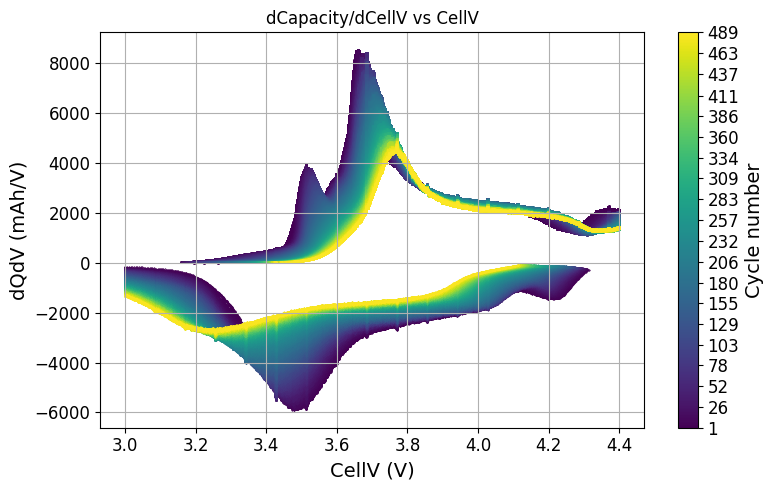

In [6]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos, dict_ciclos_sep, 'Q', 'CellV')

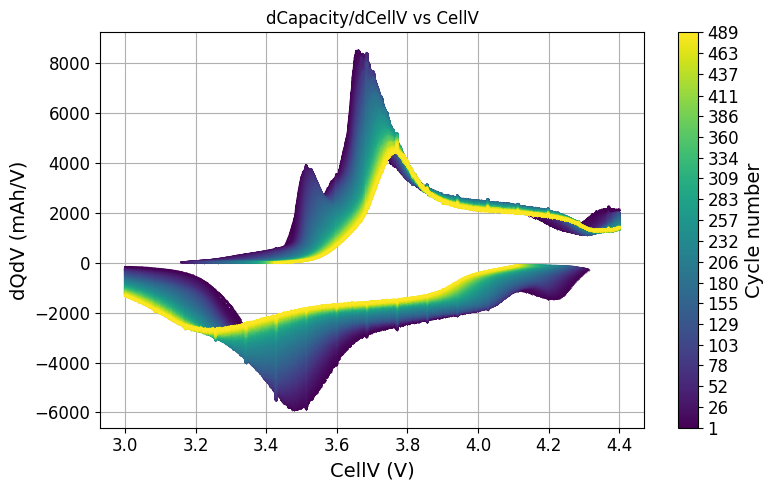

In [7]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos, dict_ciclos_sep)


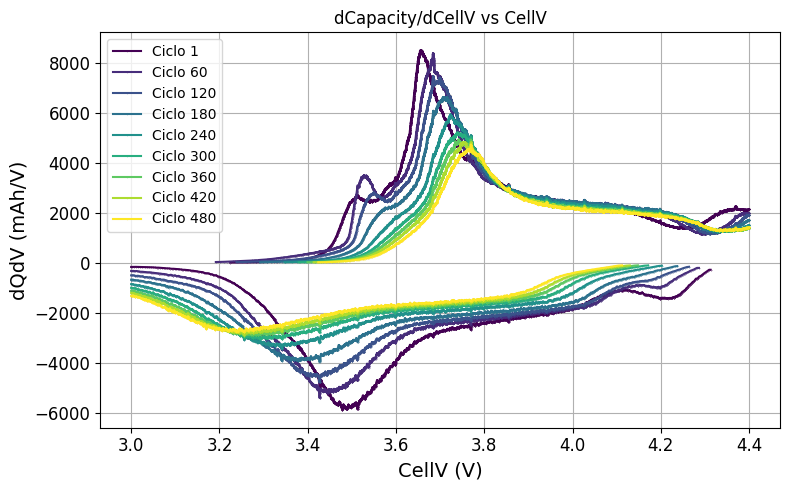

In [8]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos)) if i % 20 == 0]

pl.plot_n_cycles_dqdv(ciclos_sel_grafico, dict_ciclos_sep)


In [9]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_sep)

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: cannot convert float NaN to integer

## Pruebo parametros filtros para calcular derivada

In [10]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_sep, wl_values=[31,51,71,91,111,131,151,171,191], truncar_values=(20,60))

TypeError: plot_dqdv_muchos_wl() got an unexpected keyword argument 'wl_values'

## Calculo derivada con los parámetros dados

> En este conjunto de datos, la señal de carga tiene **3 veces más resolución** que la de descarga.  
> Estos valores pueden cambiar según el dataset.  
>  
>  wl: tamaño ventana, 
>  
> **NMC-45**  
> • ch: (wl = 453, truncar los n=60 puntos iniciales)
> • dis: (wl = 151 = 453 / 3, truncar los n=20=60/3 puntos finales)
>
> **NMC-20**  
> • ch: (wl = 153, truncar los n=30 puntos iniciales)
> • dis: (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)
>  
> **NMC-10**  
> • ch: (wl = 213, truncar los n=30 puntos iniciales)
> • dis: (wl = 71 = 153 / 3, truncar los n=10=30/3 puntos finales)

In [13]:
wl_ch = 453
wl_dis = 151
n_ch = (60,0)
n_dis = (0,20)

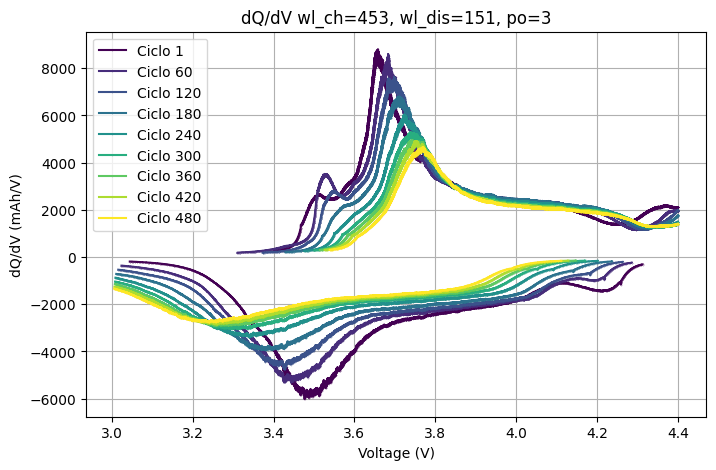

ValueError: If mode is 'interp', window_length must be less than or equal to the size of x.

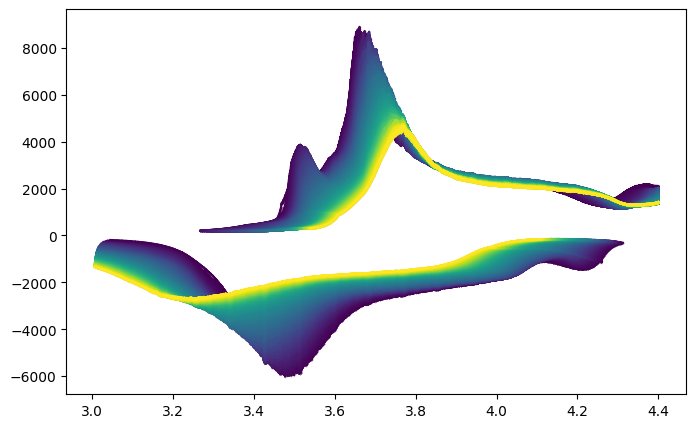

In [14]:
# --- Trunco datos y calculo derivada ---

diccio_grafico = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()}  for ciclo, df in dict_ciclos_sep.items()}
diccio_grafico = dr.truncar_señal(ciclos_sel_grafico, diccio_grafico, n_dis=n_dis, n_ch=n_ch)
diccio_grafico =  dr.plot_dqdV(ciclos_sel_grafico, diccio_grafico, wl_dis=wl_dis, wl_ch=wl_ch)

diccio_todos = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_sep.items()}
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=n_dis, n_ch=n_ch)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=wl_dis, wl_ch=wl_ch)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

# REALIZO AJUSTES

## Tests iniciales


> **NMC-45**  
> • ch: (wl = 453, truncar los n=60 puntos iniciales)

> **NMC-20**

>param_guess = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828), # Formato: (amplitud, media, sigma, lambda)
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]

> **NMC-10**

>param_guess = [(1.18755445e+03, 3.66000000e+00, 7.35838350e-02, 3.22069806e+00),   # Formato: (amplitud, media, sigma, lambda)
                (5.50463062e+02, 3.71184186e+00, 1.56909614e-02, 1.01915550e+01),
                (1.24528665e+03, 4.20488376e+00, 2.44991919e-01, 5.07773895e+00)
                ]


In [ ]:
# Indices de ciclos disponibles (todos):
# [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]

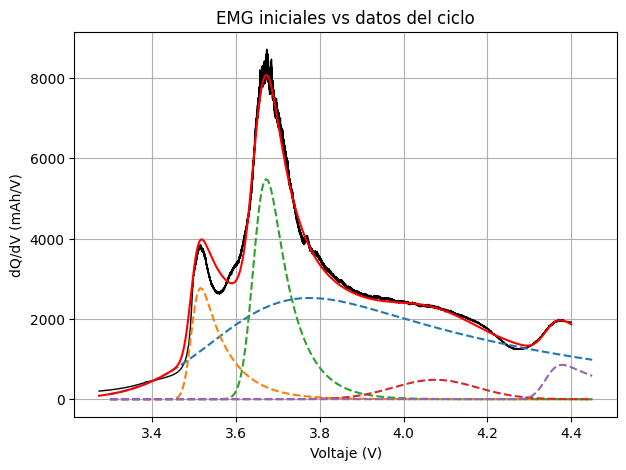

In [ ]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

df_ch = diccio_todos[21]['Ch']
param_guess = [(2440, 3.57, 0.15, 1.60279214), # Formato: (amplitud, media, sigma, lambda)
                (280, 3.49517494e+00, 0.015, 15),
                (5.98322012e+02, 3.64652378e+00, 2.30939316e-02, 1.73044167e+01),
                (1.20722302e+02, 4.06238804e+00, 9.86725905e-02, 7.49999998e+01),
                (1.80430778e+02, 4.34043541e+00, 2.39043565e-02, 6.48978323e+00)]



ft.plot_emg_guess(df_ch, param_guess, x_range=(3.3, 4.45),legend=False)

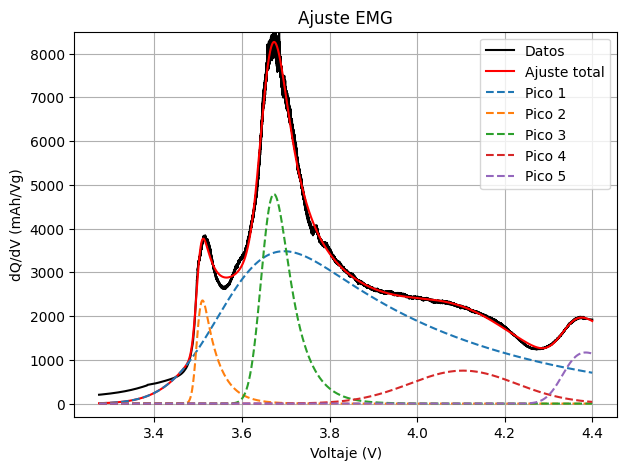

Parámetros optimizados ciclo 1 carga:
[2.19604375e+03 3.56157049e+00 9.80769891e-02 2.46461103e+00
 1.30776629e+02 3.49794597e+00 8.92540184e-03 2.84999999e+01
 4.40564419e+02 3.65074167e+00 2.26825571e-02 2.38091000e+01
 2.29372284e+02 4.09792902e+00 1.21230676e-01 1.42498208e+02
 3.41574579e+02 4.33485641e+00 3.08146139e-02 4.57265311e+00]


In [15]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
p_ini_peaks = [(2440, 3.57, 0.15, 1.60279214), # Formato: (amplitud, media, sigma, lambda)
                (280, 3.49517494e+00, 0.015, 15),
                (5.98322012e+02, 3.64652378e+00, 2.30939316e-02, 1.73044167e+01),
                (1.20722302e+02, 4.06238804e+00, 9.86725905e-02, 7.49999998e+01),
                (1.80430778e+02, 4.34043541e+00, 2.39043565e-02, 6.48978323e+00)]
p_ini_peaks_flat = np.array(p_ini_peaks).flatten()
n_peaks = len(p_ini_peaks)

# Bounds de los parámetros
config_bounds = {
    'perc_a': 0.9,           # porcentaje de variación permitido para la amplitud
    'perc_mu': 0.9,
    'perc_sigma': 0.9,
    'perc_lambda': 0.9,
    #'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}      # restricción de rango
}
bounds_emg = ft.construir_bounds(p_ini_peaks_flat, n_peaks, config_bounds)

# Ajuste del ciclo 21 de carga
df_ch_1 = diccio_todos[21]['Ch']
p_opt_1, cov_1 = ft.fit_emg_ciclo(df_ch_1, p_ini_peaks_flat, bounds_emg)
ft.plot_emg_fit(df_ch_1, p_opt_1)

print("Parámetros optimizados ciclo 1 carga:")
print(p_opt_1)

## Loop

In [16]:
timestamp = datetime.now(timezone(timedelta(hours=-3))).strftime("%Y-%m-%d_%H-%M-%S")

cfg_bounds: {'perc_a': 1.5, 'perc_mu': 1.5, 'perc_sigma': 1.5, 'perc_lambda': 1.5}
----------------------------------------
Ajustando ciclo 1...
Ajustando ciclo 3...
Ajustando ciclo 6...
Ajustando ciclo 9...
Ajustando ciclo 12...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


⚠️ Ajuste del ciclo 12 fallido: array must not contain infs or NaNs
Ajustando ciclo 15...
Ajustando ciclo 18...
Ajustando ciclo 21...


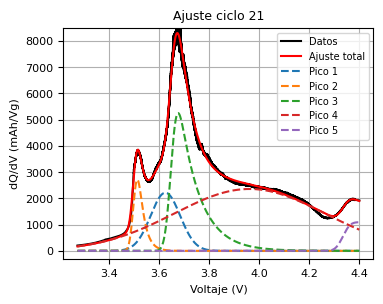

Ajustando ciclo 24...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 27...
Ajustando ciclo 30...


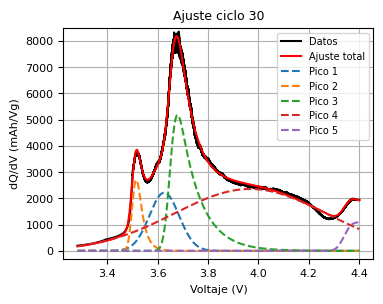

Ajustando ciclo 33...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 36...
Ajustando ciclo 39...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *


Ajustando ciclo 42...
Ajustando ciclo 45...
Ajustando ciclo 48...
Ajustando ciclo 51...
⚠️ Ajuste del ciclo 51 fallido: array must not contain infs or NaNs
Ajustando ciclo 54...
Ajustando ciclo 57...
⚠️ Ajuste del ciclo 57 fallido: array must not contain infs or NaNs
Ajustando ciclo 60...


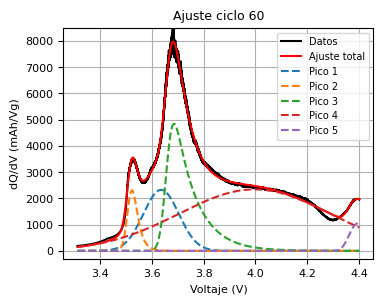

Ajustando ciclo 63...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 66...
Ajustando ciclo 69...
Ajustando ciclo 72...
Ajustando ciclo 75...
Ajustando ciclo 78...
Ajustando ciclo 81...
Ajustando ciclo 84...
⚠️ Ajuste del ciclo 84 fallido: array must not contain infs or NaNs
Ajustando ciclo 87...
⚠️ Ajuste del ciclo 87 fallido: array must not contain infs or NaNs
Ajustando ciclo 90...
⚠️ Ajuste del ciclo 90 fallido: array must not contain infs or NaNs
Ajustando ciclo 93...
Ajustando ciclo 96...
Ajustando ciclo 99...
Ajustando ciclo 102...
Ajustando ciclo 105...
Ajustando ciclo 108...
Ajustando ciclo 111...
Ajustando ciclo 114...
⚠️ Ajuste del ciclo 114 fallido: array must not contain infs or NaNs
Ajustando ciclo 117...
Ajustando ciclo 120...


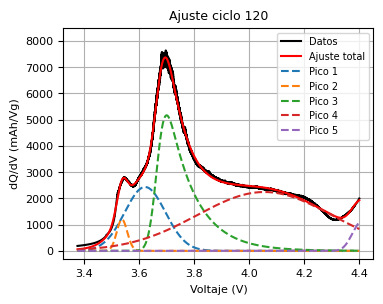

Ajustando ciclo 123...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 126...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 129...
⚠️ Ajuste del ciclo 129 fallido: array must not contain infs or NaNs
Ajustando ciclo 132...
Ajustando ciclo 135...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *


Ajustando ciclo 138...
Ajustando ciclo 141...
Ajustando ciclo 144...
⚠️ Ajuste del ciclo 144 fallido: array must not contain infs or NaNs
Ajustando ciclo 147...
Ajustando ciclo 150...
⚠️ Ajuste del ciclo 150 fallido: array must not contain infs or NaNs
Ajustando ciclo 153...
Ajustando ciclo 156...
⚠️ Ajuste del ciclo 156 fallido: array must not contain infs or NaNs
Ajustando ciclo 159...
⚠️ Ajuste del ciclo 159 fallido: array must not contain infs or NaNs
Ajustando ciclo 162...
Ajustando ciclo 165...
Ajustando ciclo 168...
⚠️ Ajuste del ciclo 168 fallido: array must not contain infs or NaNs
Ajustando ciclo 171...
Ajustando ciclo 174...
⚠️ Ajuste del ciclo 174 fallido: array must not contain infs or NaNs
Ajustando ciclo 177...
Ajustando ciclo 180...


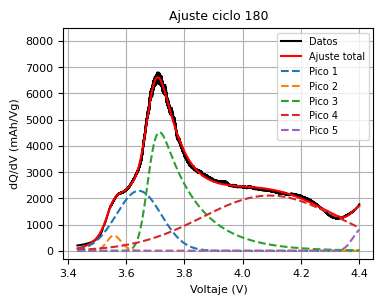

Ajustando ciclo 183...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


⚠️ Ajuste del ciclo 183 fallido: array must not contain infs or NaNs
Ajustando ciclo 186...
Ajustando ciclo 189...
Ajustando ciclo 192...
⚠️ Ajuste del ciclo 192 fallido: array must not contain infs or NaNs
Ajustando ciclo 195...
⚠️ Ajuste del ciclo 195 fallido: array must not contain infs or NaNs
Ajustando ciclo 198...
⚠️ Ajuste del ciclo 198 fallido: array must not contain infs or NaNs
Ajustando ciclo 201...
⚠️ Ajuste del ciclo 201 fallido: array must not contain infs or NaNs
Ajustando ciclo 204...
⚠️ Ajuste del ciclo 204 fallido: array must not contain infs or NaNs
Ajustando ciclo 207...
⚠️ Ajuste del ciclo 207 fallido: array must not contain infs or NaNs
Ajustando ciclo 210...
⚠️ Ajuste del ciclo 210 fallido: array must not contain infs or NaNs
Ajustando ciclo 213...
⚠️ Ajuste del ciclo 213 fallido: array must not contain infs or NaNs
Ajustando ciclo 216...
⚠️ Ajuste del ciclo 216 fallido: array must not contain infs or NaNs
Ajustando ciclo 219...
⚠️ Ajuste del ciclo 219 fallido: a

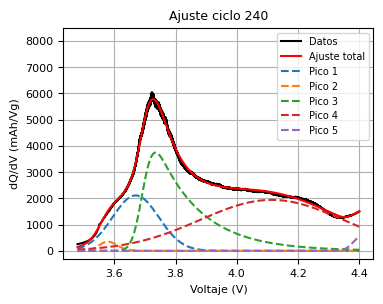

Ajustando ciclo 243...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 246...
Ajustando ciclo 249...
Ajustando ciclo 252...
Ajustando ciclo 255...
Ajustando ciclo 258...
⚠️ Ajuste del ciclo 258 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 261...
Ajustando ciclo 264...
Ajustando ciclo 267...
Ajustando ciclo 270...


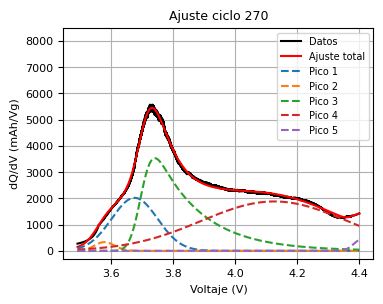

Ajustando ciclo 273...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 276...
Ajustando ciclo 279...
Ajustando ciclo 282...
Ajustando ciclo 285...
Ajustando ciclo 288...
Ajustando ciclo 291...
Ajustando ciclo 294...
Ajustando ciclo 297...
Ajustando ciclo 300...


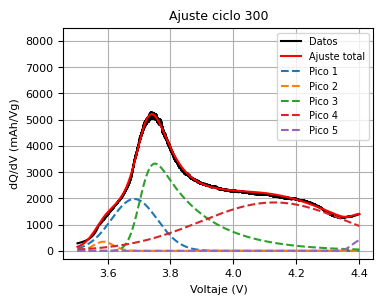

Ajustando ciclo 303...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 306...
Ajustando ciclo 309...
⚠️ Ajuste del ciclo 309 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 312...
Ajustando ciclo 315...
Ajustando ciclo 318...
Ajustando ciclo 321...
Ajustando ciclo 324...
Ajustando ciclo 327...
Ajustando ciclo 330...


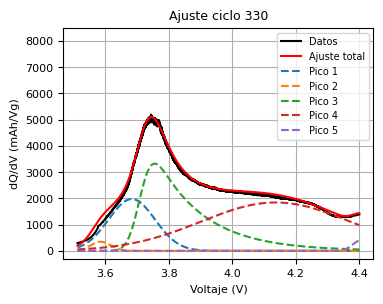

Ajustando ciclo 333...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 336...
Ajustando ciclo 339...
Ajustando ciclo 342...
Ajustando ciclo 345...
Ajustando ciclo 348...
Ajustando ciclo 351...
Ajustando ciclo 354...
Ajustando ciclo 357...
⚠️ Ajuste del ciclo 357 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 360...


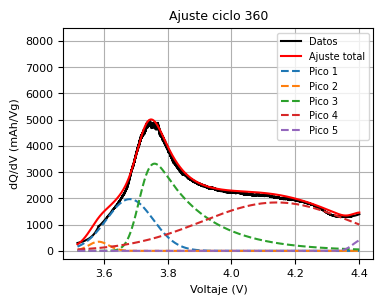

Ajustando ciclo 363...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 366...
Ajustando ciclo 369...
Ajustando ciclo 372...
Ajustando ciclo 375...
Ajustando ciclo 378...
Ajustando ciclo 381...
Ajustando ciclo 384...
Ajustando ciclo 387...
Ajustando ciclo 390...


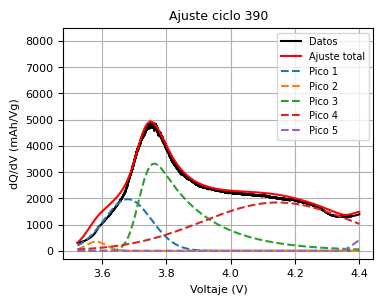

Ajustando ciclo 393...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 396...
Ajustando ciclo 399...
Ajustando ciclo 402...
Ajustando ciclo 405...
Ajustando ciclo 408...
Ajustando ciclo 411...
Ajustando ciclo 414...
⚠️ Ajuste del ciclo 414 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 417...
Ajustando ciclo 420...


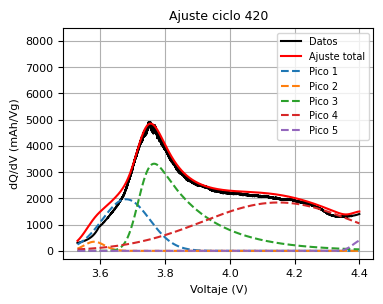

Ajustando ciclo 423...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *


Ajustando ciclo 426...
Ajustando ciclo 429...
Ajustando ciclo 432...
Ajustando ciclo 435...
Ajustando ciclo 438...
Ajustando ciclo 441...
Ajustando ciclo 444...
Ajustando ciclo 447...
Ajustando ciclo 450...


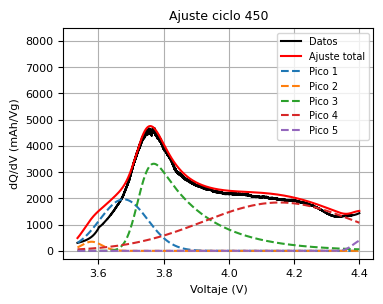

Ajustando ciclo 453...
⚠️ Ajuste del ciclo 453 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 456...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 459...
Ajustando ciclo 462...
Ajustando ciclo 465...
Ajustando ciclo 468...
Ajustando ciclo 471...
Ajustando ciclo 474...
Ajustando ciclo 477...
Ajustando ciclo 480...


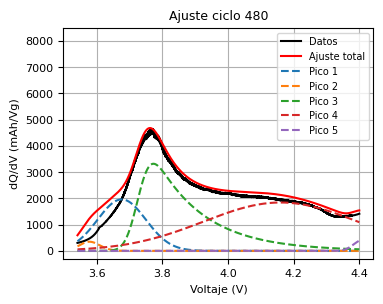

Ajustando ciclo 483...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 486...
✅ Ajustes terminados. Resultados guardados en '../output/parametros_ajustes_NMC-45C-parte1-cada3_EMG_2025-12-02_09-23-02.csv'


In [86]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop, nombre del .csv, parámetros iniciales y bounds ------------------
nombre_ajuste = f'{nombre_dataset}_EMG_{timestamp}'
ciclos_ajustar = [c for c in ciclos_sel_todos] #if 0 <= c <= 900]
ciclos_graficar = [c for c in ciclos_ajustar if c == 21 or c % 10 == 0]


# Parámetros iniciales por pico
p_ini_peaks = [(2440, 3.57, 0.15, 1.60279214), # Formato: (amplitud, media, sigma, lambda)
                (280, 3.49517494e+00, 0.015, 15),
                (5.98322012e+02, 3.64652378e+00, 2.30939316e-02, 1.73044167e+01),
                (1.20722302e+02, 4.06238804e+00, 9.86725905e-02, 7.49999998e+01),
                (1.80430778e+02, 4.34043541e+00, 2.39043565e-02, 6.48978323e+00)]

p_ini_peaks_flat = np.array(p_ini_peaks).flatten() # aplanado
n_peaks = len(p_ini_peaks)

# Bounds de los parámetros 1er ajuste
config_bounds_ini = {
    'perc_a': 1.5,           # porcentaje de variación permitido para la amplitud
    'perc_mu': 1.5,
    'perc_sigma': 1.5,
    'perc_lambda': 1.5,
    #'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}      # restricción de rango
}
bounds_emg_ini = ft.construir_bounds(p_ini_peaks_flat, n_peaks, config_bounds_ini)

# Bounds de los parámetros demás ajustes
config_bounds_loop = {
    'perc_a': 1.5,           # porcentaje de variación permitido para la amplitud
    'perc_mu': 1.5,
    'perc_sigma': 1.5,
    'perc_lambda': 1.5,
    #'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}      # restricción de rango
}
bounds_emg_loop = ft.construir_bounds(p_ini_peaks_flat, n_peaks, config_bounds_loop)
# ----------------------------------------------------------------------------------------------

parametros, covs = ft.fitloop_emg(
    diccio_todos,
    ciclos=ciclos_ajustar,
    p_ini_emg=p_ini_peaks_flat,
    bounds_ini_emg=bounds_emg_ini,
    ciclos_grafico=ciclos_graficar,
    cfg_bounds=config_bounds_loop
)

df_parametros = ft.guardar_parametros_emg(parametros, ciclos_sel_todos, nombre_ajuste)

# Ploteo datos ya ajustados

In [17]:
# --- Trabajo con parámetros previamente ajustados ---

archivo = "../output/parametros_ajustes_NMC-45C-parte1-cada3_EMG_2025-12-01_19-17-29.csv"

df_param = pd.read_csv(archivo, index_col=0)
df_param.head()

,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4,a5,mu5,sigma5,lambda5
1,2427.463812,3.586154,0.120000,1.923351,224.000000,3.482209,0.018000,12.0000,508.111903,3.636880,0.018475,17.681171,96.577842,4.074500,0.091999,60.000000,216.516934,4.322539,0.028685,7.748557
3,2365.672644,3.577809,0.096000,2.104401,227.268446,3.483336,0.014400,14.4000,453.018255,3.641392,0.020465,21.217406,107.748341,4.064073,0.085875,48.000000,259.820320,4.319021,0.034422,6.229368
6,2294.523981,3.578050,0.104362,2.303279,202.779608,3.487592,0.011520,17.2800,452.778796,3.644650,0.022537,23.819567,129.298010,4.069455,0.089391,41.337577,311.784384,4.320138,0.039162,5.318745
9,2293.115949,3.566309,0.105976,2.274187,165.791979,3.491197,0.009216,20.7360,470.213862,3.644531,0.022494,21.933395,155.157611,4.073436,0.099893,49.605092,353.939127,4.321751,0.034306,4.254996
12,2226.224899,3.568741,0.108117,2.550592,142.873184,3.493355,0.008682,24.8832,441.330068,3.648579,0.024554,26.320073,186.189134,4.086961,0.105246,59.526110,424.726951,4.323747,0.034919,3.730300


## Gráfico de un ciclo en particular

In [18]:
# --- Plot de un ciclo en particular ---

# ------ Elegir cuál y de qué loop ---------------
ciclo = 45
df_param = pd.read_csv(archivo, index_col=0)
nombre = nombre_dataset # etiqueta gráfico
# ------------------------------------------------

# Ajuste del ciclo i de carga
df_ch_i = diccio_todos[ciclo]['Ch']
popt_i = df_param.loc[ciclo].values

#ft.plot_emg_fit(df_ch_i, popt_i, save_path=f'../output/ajuste_C{ciclo}_{nombre}.png', nombre_ciclo=ciclo)

## Evolución parámetros

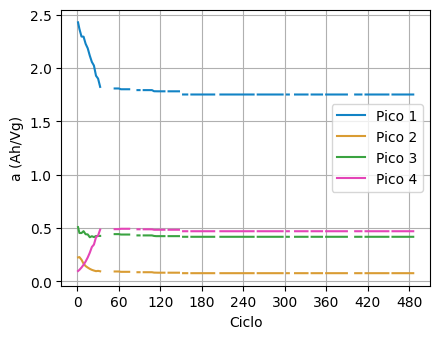

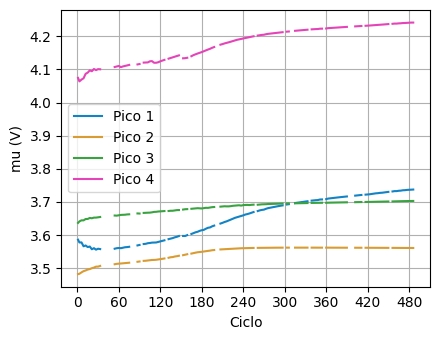

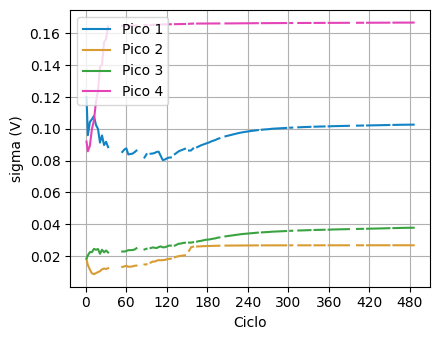

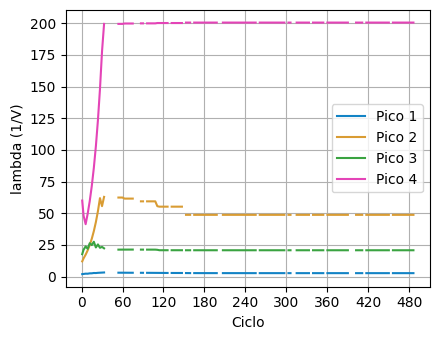

In [19]:
# ------ Elegir de qué loop ---------------
df_params = pd.read_csv(archivo, index_col=0)
nombre = nombre_dataset # etiqueta gráfico
# ------------------------------------------------

#print(df_params.index)
n_peaks = 4

# Graficar todos los parámetros
for p in ['a', 'mu', 'sigma', 'lambda']:
    ft.plot_param_evolution(df_params, p, n_peaks, nombre, exclude_peaks=[])